# Radioactive Decay Simulation

This notebook simulates the decay of a radioactive substance over time. The decay process is modeled using the concept of exponential decay, which can be related to random number generation as it involves probabilistic outcomes.

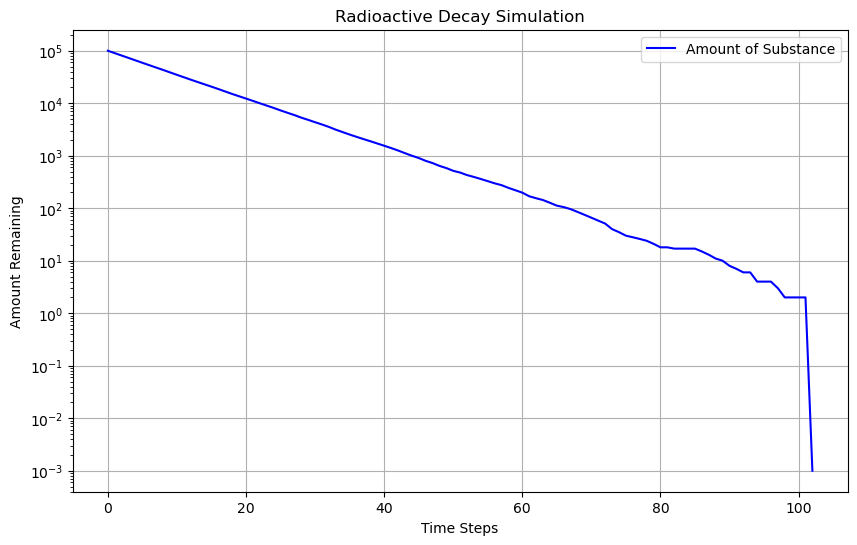

In [14]:
import numpy as np
import matplotlib.pyplot as plt

def radioactive_decay(initial_amount, decay_constant, time_steps):
    """
    Simulate radioactive decay over a specified number of time steps.
    Parameters:
    initial_amount: Initial quantity of the substance.
    decay_constant: Decay constant (lambda) for the substance.
    time_steps: Maximum number of time steps to simulate.
    The simulation will stop early once the amount reaches 1 or less.
    """
    amounts = np.zeros(time_steps)
    amounts[0] = initial_amount
    for t in range(1, time_steps):
        decay = np.random.poisson(amounts[t-1] * decay_constant)
        amounts[t] = amounts[t-1] - decay
        if amounts[t] < 0:
            amounts[t] = 0
        # Stop once the amount is 1 or less and return the truncated array
        if amounts[t] <= 1:
            return amounts[:t+1]
    return amounts

# Parameters for the simulation
initial_amount = 100000  # Initial quantity of substance
decay_constant = 0.1    # Decay constant
time_steps = 1000        # Maximum number of time steps

# Run the simulation
decay_amounts = radioactive_decay(initial_amount, decay_constant, time_steps)

# Clip zeros so we can use a logarithmic y-scale
decay_amounts_safe = np.clip(decay_amounts, a_min=1e-3, a_max=None)

# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(decay_amounts_safe, label='Amount of Substance', color='blue')
plt.yscale('log')
plt.title('Radioactive Decay Simulation')
plt.xlabel('Time Steps')
plt.ylabel('Amount Remaining')
plt.grid(True)
plt.legend()
plt.show()

#### JC: I noticed and remembered that this should actually be a random decay constant at every time step. Im gonna ask it to make a code that includes Fixed vs random

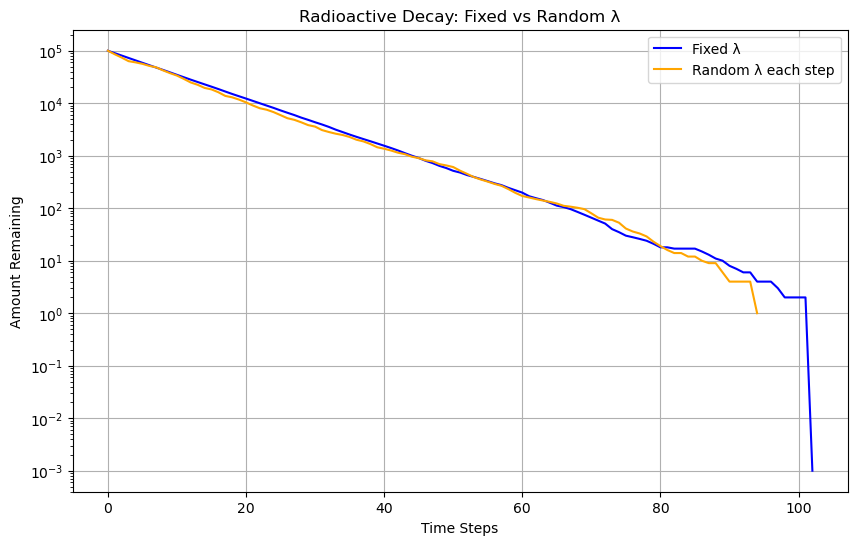

In [15]:
def radioactive_decay_random_lambda(initial_amount, base_decay_constant, time_steps):
    """
    Simulate radioactive decay where the decay constant λ is randomly
    re-sampled at each time step using a uniform distribution around the
    base decay constant.
    The simulation will stop early once the amount reaches 1 or less.
    """
    amounts = np.zeros(time_steps)
    amounts[0] = initial_amount
    for t in range(1, time_steps):
        # Draw a new lambda (decay constant) for this time step
        decay_constant_t = np.random.uniform(0.5 * base_decay_constant, 1.5 * base_decay_constant)
        decay = np.random.poisson(amounts[t-1] * decay_constant_t)
        amounts[t] = amounts[t-1] - decay
        if amounts[t] < 0:
            amounts[t] = 0
        # Stop once the amount is 1 or less and return the truncated array
        if amounts[t] <= 1:
            return amounts[:t+1]
    return amounts

# Run the simulation with random lambda at each time step
decay_amounts_random = radioactive_decay_random_lambda(initial_amount, decay_constant, time_steps)

# Clip zeros for log-scale plotting
decay_amounts_random_safe = np.clip(decay_amounts_random, a_min=1e-3, a_max=None)

# Plot both fixed-lambda and random-lambda simulations for comparison
plt.figure(figsize=(10, 6))
plt.plot(decay_amounts_safe, label='Fixed λ', color='blue')
plt.plot(decay_amounts_random_safe, label='Random λ each step', color='orange')
plt.yscale('log')
plt.title('Radioactive Decay: Fixed vs Random λ')
plt.xlabel('Time Steps')
plt.ylabel('Amount Remaining')
plt.grid(True)
plt.legend()
plt.show()

#### JC: this is to be expected because it wouldnt have a consistent logarithmic slope at all when there would be lambda changes at every time step. How i know this is also done right when it goes to a lower N value its more random and less exponential like rather than 10^7

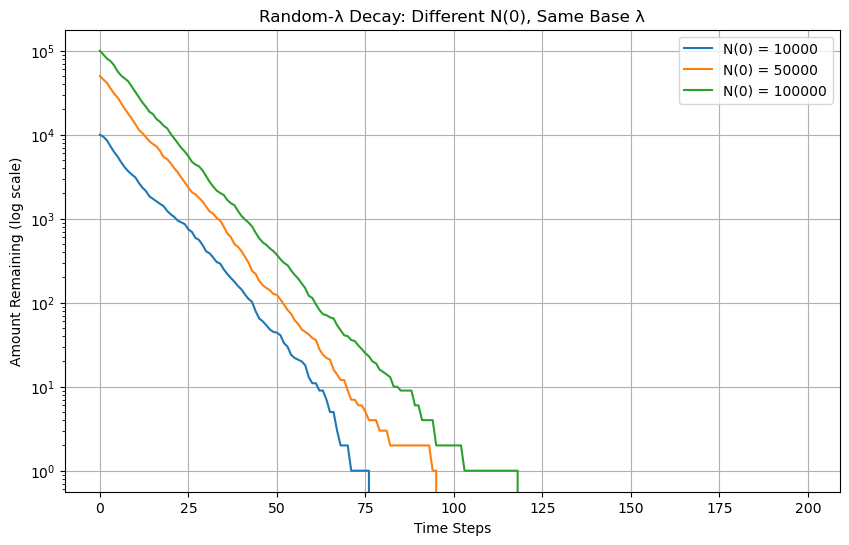

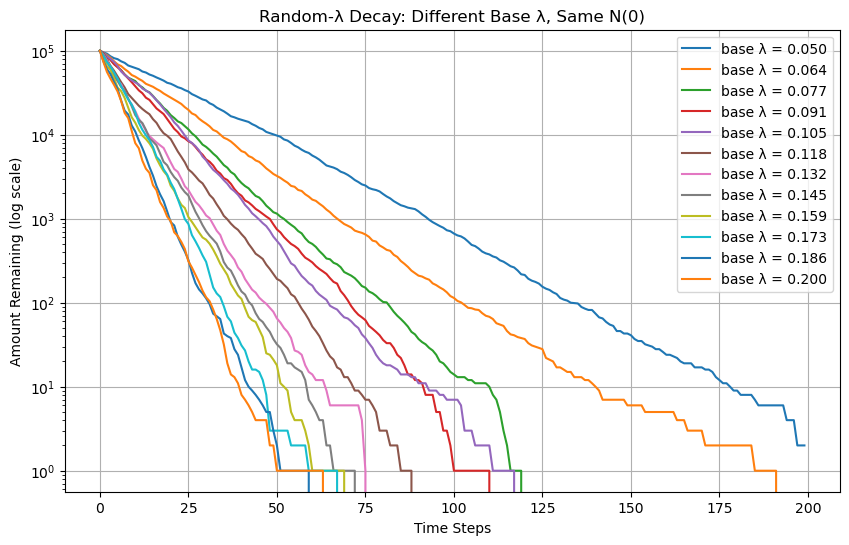

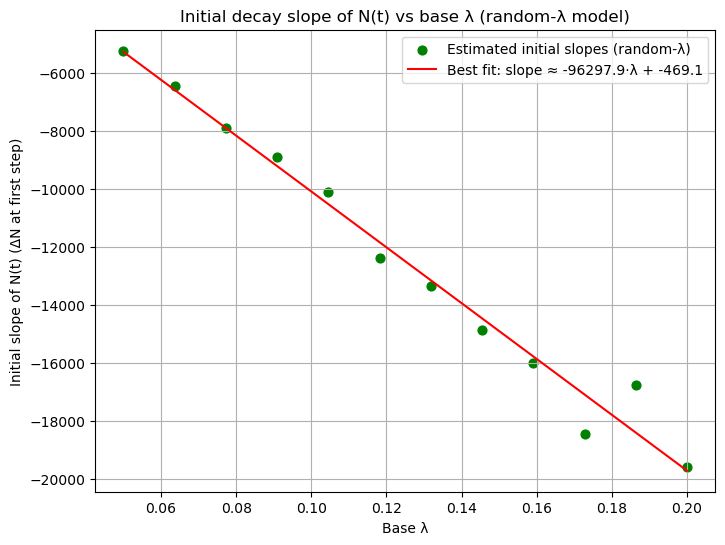

In [21]:
import numpy as np
import matplotlib.pyplot as plt

def radioactive_decay_random_lambda_no_stop(initial_amount, base_decay_constant, time_steps):
    """
    Simulate radioactive decay without early stopping, where the
    decay constant λ is randomly re-sampled at each time step
    around a base value.
    """
    amounts = np.zeros(time_steps)
    amounts[0] = initial_amount
    for t in range(1, time_steps):
        # Draw a new lambda (decay constant) for this time step
        decay_constant_t = np.random.uniform(0.5 * base_decay_constant, 1.5 * base_decay_constant)
        decay = np.random.poisson(amounts[t-1] * decay_constant_t)
        amounts[t] = amounts[t-1] - decay
        if amounts[t] < 0:
            amounts[t] = 0
    return amounts

# Common settings for the comparisons
time_steps_demo = 200
lambda_demo = 0.1

# 1) Slopes vs time for different initial amounts N(0) at fixed base lambda,
#    with λ varying randomly at each time step
initial_values = [10000, 50000, 100000]
plt.figure(figsize=(10, 6))
for N0 in initial_values:
    amounts = radioactive_decay_random_lambda_no_stop(N0, lambda_demo, time_steps_demo)
    plt.plot(amounts, label=f'N(0) = {N0}')
plt.yscale('log')
plt.title('Random-λ Decay: Different N(0), Same Base λ')
plt.xlabel('Time Steps')
plt.ylabel('Amount Remaining (log scale)')
plt.grid(True)
plt.legend()
plt.show()

# 2) Slopes vs time for different base lambda at fixed N(0),
#    with λ varying randomly around each base value
lambdas = np.linspace(0.05, 0.2, 12)  # more λ values
N0_fixed = 100000
plt.figure(figsize=(10, 6))
for lam in lambdas:
    amounts = radioactive_decay_random_lambda_no_stop(N0_fixed, lam, time_steps_demo)
    plt.plot(amounts, label=f'base λ = {lam:.3f}')
plt.yscale('log')
plt.title('Random-λ Decay: Different Base λ, Same N(0)')
plt.xlabel('Time Steps')
plt.ylabel('Amount Remaining (log scale)')
plt.grid(True)
plt.legend()
plt.show()

# 3) Show that the initial slopes of N(t) are proportional to the base λ
#    for the random-λ model as well, using many λ values
lambdas_random = np.linspace(0.05, 0.2, 12)
N0_random = 100000
num_runs_random = 50  # average over many runs to reduce noise
slopes_random = []

for lam in lambdas_random:
    slope_samples = []
    for _ in range(num_runs_random):
        amounts = radioactive_decay_random_lambda_no_stop(N0_random, lam, time_steps_demo)
        # Approximate initial slope dN/dt at t=0 by the first step change
        delta0 = amounts[1] - amounts[0]  # negative value
        slope_samples.append(delta0)
    slopes_random.append(np.mean(slope_samples))

plt.figure(figsize=(8, 6))
plt.scatter(lambdas_random, slopes_random, color='green', s=40,
            label='Estimated initial slopes (random-λ)')

# Fit a straight line slope ≈ a * λ + b
m_r, b_r = np.polyfit(lambdas_random, slopes_random, 1)
lambda_line_r = np.linspace(min(lambdas_random), max(lambdas_random), 200)
plt.plot(lambda_line_r, m_r * lambda_line_r + b_r, color='red',
         label=f'Best fit: slope ≈ {m_r:.1f}·λ + {b_r:.1f}')

plt.xlabel('Base λ')
plt.ylabel('Initial slope of N(t) (ΔN at first step)')
plt.title('Initial decay slope of N(t) vs base λ (random-λ model)')
plt.grid(True)
plt.legend()
plt.show()

#### JC: This correlates with my assumptions that it would fit linearly onto the line but it would also have some deviations due to the random base lambda

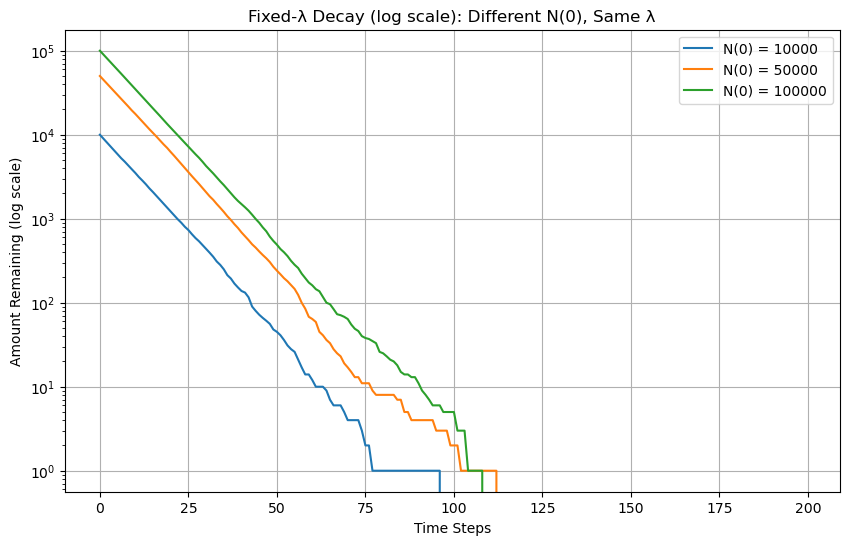

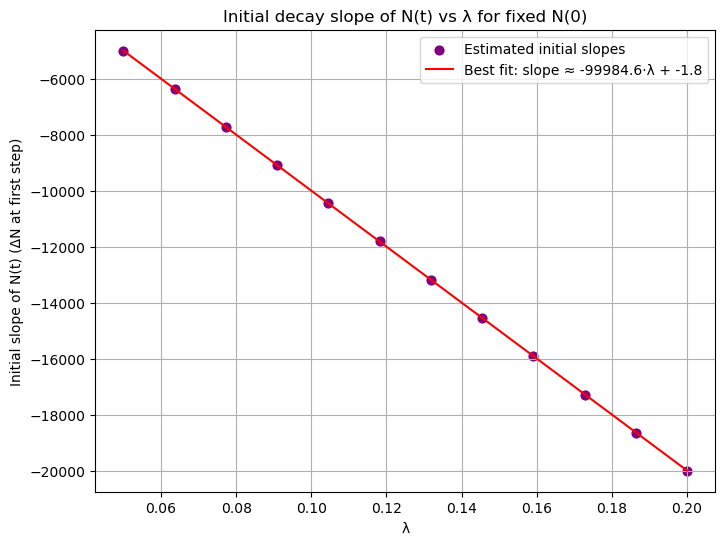

In [22]:
# Comparison with fixed λ at each time step (no randomness in λ),
# using logarithmic scaling for the amount.

import numpy as np
import matplotlib.pyplot as plt

def radioactive_decay_fixed_lambda_no_stop(initial_amount, decay_constant, time_steps):
    """
    Simulate radioactive decay with a fixed decay constant λ at each time step,
    without early stopping, for slope comparisons.
    """
    amounts = np.zeros(time_steps)
    amounts[0] = initial_amount
    for t in range(1, time_steps):
        decay = np.random.poisson(amounts[t-1] * decay_constant)
        amounts[t] = amounts[t-1] - decay
        if amounts[t] < 0:
            amounts[t] = 0
    return amounts

# Common settings
time_steps_demo_fixed = 200
lambda_demo_fixed = 0.1

# 1) Different initial amounts N(0), same fixed λ
initial_values_fixed = [10000, 50000, 100000]
plt.figure(figsize=(10, 6))
for N0 in initial_values_fixed:
    amounts = radioactive_decay_fixed_lambda_no_stop(N0, lambda_demo_fixed, time_steps_demo_fixed)
    plt.plot(amounts, label=f'N(0) = {N0}')
plt.yscale('log')
plt.title('Fixed-λ Decay (log scale): Different N(0), Same λ')
plt.xlabel('Time Steps')
plt.ylabel('Amount Remaining (log scale)')
plt.grid(True)
plt.legend()
plt.show()

# 2) Show that the initial slopes of N(t) are proportional to λ for a fixed N(0)
#    Use many λ values to get more points.
lambdas_fixed = np.linspace(0.05, 0.2, 12)  # 12 λ values between 0.05 and 0.2
N0_fixed_fixed = 100000
num_runs = 50  # average over many runs to reduce noise
slopes = []

for lam in lambdas_fixed:
    slope_samples = []
    for _ in range(num_runs):
        amounts = radioactive_decay_fixed_lambda_no_stop(N0_fixed_fixed, lam, time_steps_demo_fixed)
        # Approximate initial slope dN/dt at t=0 by the first step change
        delta0 = amounts[1] - amounts[0]  # negative value
        slope_samples.append(delta0)
    # Use the mean initial slope for this λ
    slopes.append(np.mean(slope_samples))

plt.figure(figsize=(8, 6))
plt.scatter(lambdas_fixed, slopes, color='purple', s=40, label='Estimated initial slopes')

# Fit a straight line slope ≈ a * λ + b (expect approximately linear)
m, b = np.polyfit(lambdas_fixed, slopes, 1)
lambda_line = np.linspace(min(lambdas_fixed), max(lambdas_fixed), 200)
plt.plot(lambda_line, m * lambda_line + b, color='red',
         label=f'Best fit: slope ≈ {m:.1f}·λ + {b:.1f}')

plt.xlabel('λ')
plt.ylabel('Initial slope of N(t) (ΔN at first step)')
plt.title('Initial decay slope of N(t) vs λ for fixed N(0)')
plt.grid(True)
plt.legend()
plt.show()

#### I wanted to compare it to a fixed lambda and this one is exactly proportional to the slope which isnt what we wnat to simulate randomness.

### Question 3:

assumptions, I think its gonna vary at the end where the highest points are because that has the highest value of Ns and would be consistent with an exponential curve just like in question 1

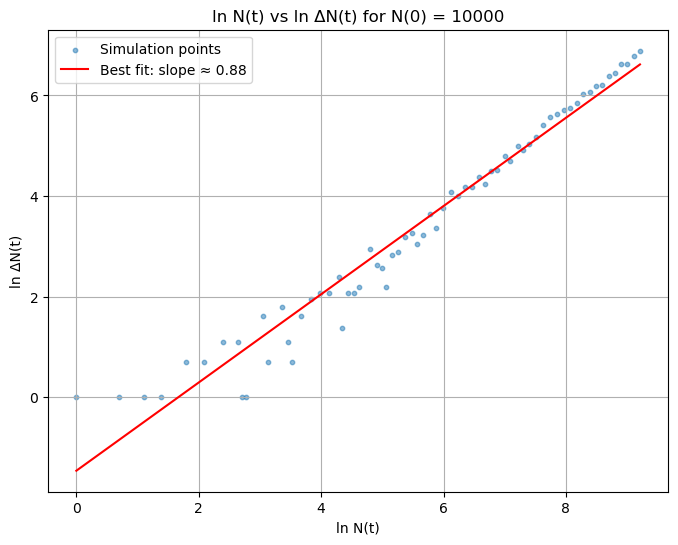

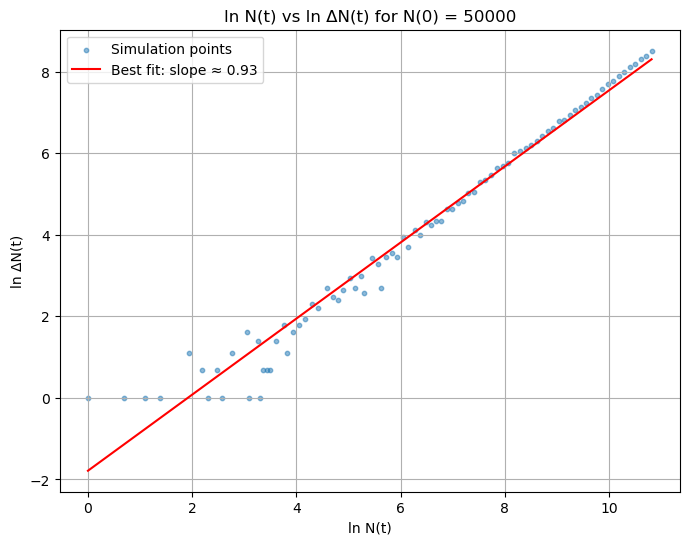

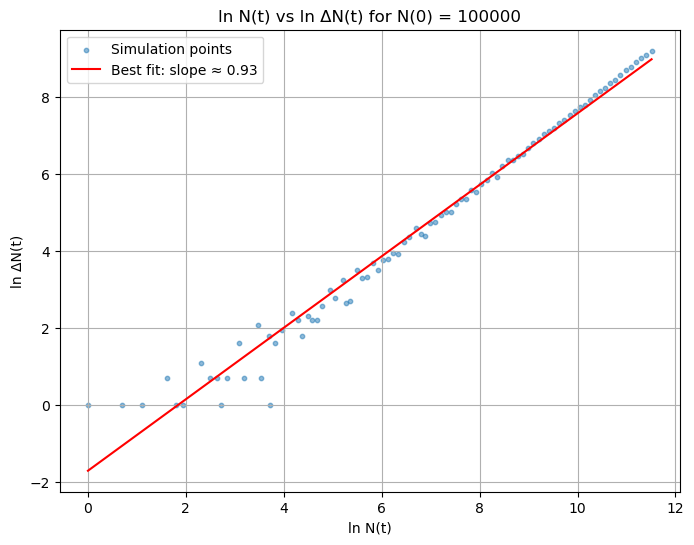

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# Show that ln N(t) and ln ΔN(t) are proportional (ΔN(t) = N(t) - N(t+1))

# We will do this for three different initial N(0) values,
# and create a separate graph for each one.

lambda_corr = 0.1
time_steps_corr = 5000
N0_values_corr = [10000, 50000, 100000]

for N0_corr in N0_values_corr:
    # Use the fixed-λ, no-stop decay to get a long time series
    amounts = radioactive_decay_fixed_lambda_no_stop(N0_corr, lambda_corr, time_steps_corr)
    
    # Compute ΔN(t) as the number of particles that decayed between t and t+1
    N_t = amounts[:-1]
    deltaN_t = N_t - amounts[1:]
    
    # Keep only steps where both N(t) and ΔN(t) are positive
    mask = (N_t > 0) & (deltaN_t > 0)
    N_t_pos = N_t[mask]
    deltaN_t_pos = deltaN_t[mask]
    
    lnN = np.log(N_t_pos)
    lnDeltaN = np.log(deltaN_t_pos)
    
    plt.figure(figsize=(8, 6))
    plt.scatter(lnN, lnDeltaN, s=10, alpha=0.5, label='Simulation points')
    
    # Fit a straight line ln ΔN = a + b ln N (expect b ≈ 1)
    m, b = np.polyfit(lnN, lnDeltaN, 1)
    x_line = np.linspace(lnN.min(), lnN.max(), 100)
    plt.plot(x_line, m * x_line + b, color='red',
             label=f'Best fit: slope ≈ {m:.2f}')
    
    plt.xlabel('ln N(t)')
    plt.ylabel('ln ΔN(t)')
    plt.title(f'ln N(t) vs ln ΔN(t) for N(0) = {N0_corr}')
    plt.grid(True)
    plt.legend()
    plt.show()

#### This exactly followed my predictions.

### Question 5:

##### A process that is spontaneos and random can lead to an exponential decay if given enough data points and tries. This is due to the fact that each time it is removing the amount of Particles by a random factor of itself which is fundamentally an exponential problem. But there are variations like in the random lambda values where the slope doesnt fit an exact exponential due to the fact that it is random. It follows a general exponential decay form because in nature it is decreasing as an exponential more than anything else.

##### And also the function serves as a derivative of N  = -N. Which we know from Math Methods the function is only of the form of an exponetial.


### Question 6:

##### Logarithmic scaling a exponential function will give you a linear function because the natural log of a exponential of time(t), is a linear function(t). In addition to that if we logarithm scale a power law function it would look like a negative logarithmic function of the form log N = -alog(Bt)